# Análise Exploratória e Tratamento de Dados

Teste de Hip para MCAR : rejeitamos. dados ausentes dependem de alguma forma das outras colunas.

Teste de Kolmogorov Smirnof para ver se gamma ou log-normal se ajustavam melhor a distrib de Y.

Validação

Imputação: link (g) = identidade, dist. log(y) normal.

Hips:

1- Y é explicada por X

2-  conjunto paramétrico de distribuição família exponencial para Y

3- g conecta a esperança de Y a soma das f_i - a média da resposta de y transformada por g é aditiva nos efeitos das varivaveis x_i's.

4-Não há iteração entre as variáveis - efeitos independentes.

5- Observações independentes.

E, como estamos usandos splines, estamos assumindo que as f_i's são suaves.

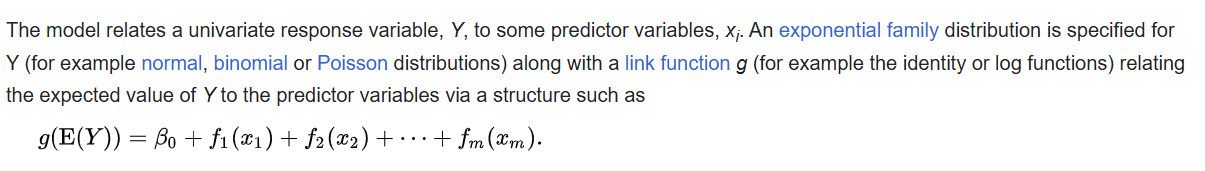

https://rianneschouten.github.io/pyampute/build/html/pyampute.exploration.html

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyampute.exploration.mcar_statistical_tests import MCARTest

In [ ]:
#dictionary = pd.read_csv(r"~\ML1\Data Dictionary.csv", index_col=0) # dicionario das features
df_tr = pd.read_csv(r"/home/al.vinicius.maciel/ML1/cs-training.csv", index_col=0) # dataframe de treino sem o índice
df_te  = pd.read_csv(r"/home/al.vinicius.maciel/ML1/cs-test.csv",  index_col=0) # dataframe de teste sem o índice
df_s = pd.read_csv(r"/home/al.vinicius.maciel/ML1/sampleEntry.csv", index_col=0) # dataframe de amostra de submissão

print("TRAIN shape:", df_tr.shape)
print("TEST  shape:", df_te.shape)
print("SAMPLE shape:", df_s.shape)

TRAIN shape: (150000, 11)
TEST  shape: (101503, 11)
SAMPLE shape: (101503, 1)


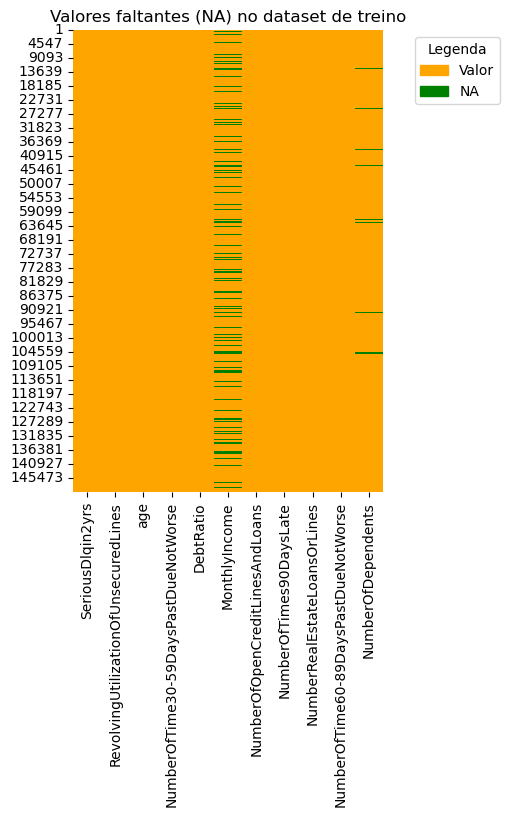

In [ ]:
composite_train = df_tr.isna().astype(int)

colors = ['orange', 'green']  # 0 = Valor, 1 = NaN
custom_cmap = sns.color_palette(colors)

plt.figure(figsize=(4, 6))
sns.heatmap(composite_train, cbar=False, cmap=custom_cmap, vmax=1, vmin=0)
handles = [plt.Rectangle((0,0),1,1, color=custom_cmap[i]) for i in range(len(colors))]
plt.legend(handles, ["Valor", "NA"], title="Legenda", loc="upper right", bbox_to_anchor=(1.4, 1))
plt.title("Valores faltantes (NA) no dataset de treino")
plt.show()

In [ ]:
df_te = df_te.drop(columns=['SeriousDlqin2yrs'])


df_te['SeriousDlqin2yrs'] = df_s['Probability']

print(f"Novo shape do df_te:", df_te.shape)
df_te.head()

Novo shape do df_te: (101503, 11)


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SeriousDlqin2yrs
1,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0,0.080807
2,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0,0.040719
3,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0,0.011968
4,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0,0.067640
5,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0,0.108264


In [ ]:
df_c = pd.concat(
    [df_tr, df_te],
    axis=0,
    ignore_index=True
)

print(df_c.shape)


(251503, 11)


In [ ]:
df_c.dropna(subset=['NumberOfDependents'], inplace=True)

In [ ]:
mcar_tester = MCARTest(method='little')

pv = mcar_tester.little_mcar_test(df_c)

pv

0.0

In [ ]:
renda_sem_nan = df_c['MonthlyIncome'].dropna()

quartis = renda_sem_nan.quantile([0.25, 0.5, 0.75, 0.9, 0.99, 0.9999])
print(quartis)

print(renda_sem_nan.skew())
print(renda_sem_nan.max())
print(renda_sem_nan.min())

0.2500      3400.00
0.5000      5400.00
0.7500      8212.00
0.9000     11600.00
0.9900     25050.36
0.9999    438040.10
Name: MonthlyIncome, dtype: float64
195.75627387813304
7727000.0
0.0


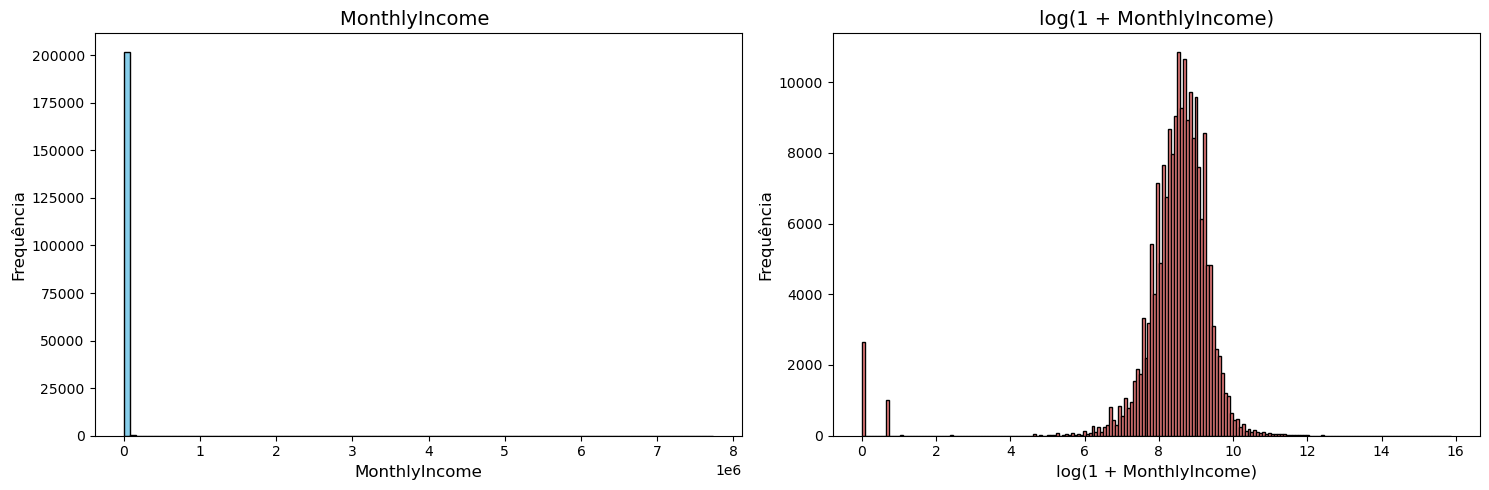

In [ ]:
renda_original = df_c['MonthlyIncome'].dropna()

renda_log = np.log1p(renda_original)


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(renda_original, bins=100, color='skyblue', edgecolor='black')
axes[0].set_title('MonthlyIncome ', fontsize=14)
axes[0].set_xlabel('MonthlyIncome', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)

axes[1].hist(renda_log, bins=200, color='lightcoral', edgecolor='black')
axes[1].set_title('log(1 + MonthlyIncome)', fontsize=14)
axes[1].set_xlabel('log(1 + MonthlyIncome)', fontsize=12)
axes[1].set_ylabel('Frequência', fontsize=12)

plt.tight_layout()
plt.show()

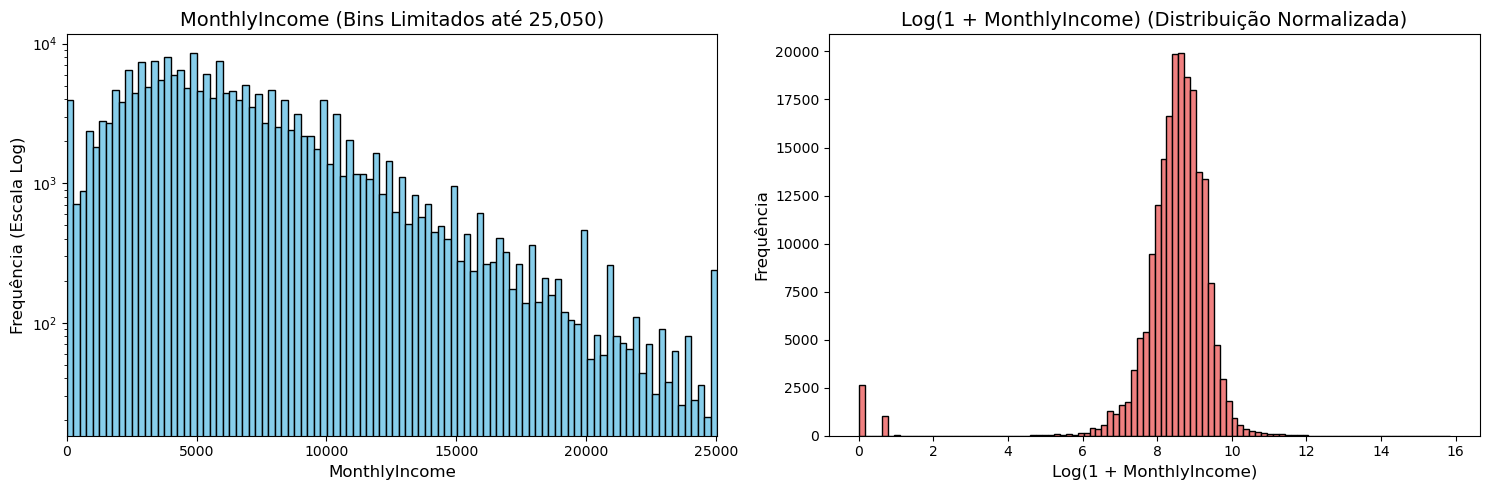

O limite de corte usado para criar os bins foi o 99º percentil: R$ 25,050.36


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare os dados (remover NaN)
renda_original = df_c['MonthlyIncome'].dropna()
renda_log = np.log1p(renda_original)

# 2. Definir o novo limite para o cálculo dos BINS
# Vamos usar o 99º percentil para incluir 99% dos dados
limite_para_bins = renda_original.quantile(0.99)


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Histograma da Renda Original (CORRIGIDO) ---

# AQUI ESTÁ A MUDANÇA ESSENCIAL:
# Usamos 'range=(0, limite_para_bins)' para que os 100 bins sejam criados
# de forma uniforme APENAS dentro desta faixa de 0 a limite_para_bins.
axes[0].hist(
    renda_original,
    bins=100,
    range=(0, limite_para_bins),
    color='skyblue',
    edgecolor='black'
)

axes[0].set_title(f'MonthlyIncome (Bins Limitados até {limite_para_bins:,.0f})', fontsize=14)
axes[0].set_xlabel('MonthlyIncome', fontsize=12)
axes[0].set_ylabel('Frequência (Escala Log)', fontsize=12)

# Manter a escala logarítmica no Eixo Y ajuda a ver a diferença entre as barras
axes[0].set_yscale('log')

# O set_xlim agora é redundante, mas confirma o limite visual
axes[0].set_xlim(0, limite_para_bins)


# --- Histograma da Renda Transformada (Log) ---
axes[1].hist(renda_log, bins=100, color='lightcoral', edgecolor='black')
axes[1].set_title('Log(1 + MonthlyIncome) (Distribuição Normalizada)', fontsize=14)
axes[1].set_xlabel('Log(1 + MonthlyIncome)', fontsize=12)
axes[1].set_ylabel('Frequência', fontsize=12)

plt.tight_layout()
plt.show()

print(f"O limite de corte usado para criar os bins foi o 99º percentil: R$ {limite_para_bins:,.2f}")

In [ ]:
from scipy.stats import lognorm, gamma, kstest

renda_original = renda_original + 1

params_lognorm = lognorm.fit(renda_original)
s_ln, loc_ln, scale_ln = params_lognorm


params_gamma = gamma.fit(renda_original)
a_g, loc_g, scale_g = params_gamma


ks_stat_ln, p_value_ln = kstest(renda_original, 'lognorm', args=params_lognorm)

ks_stat_g, p_value_g = kstest(renda_original, 'gamma', args=params_gamma)

print("\n LOG-NORMAL")
print(f"KS Statistic (D): {ks_stat_ln:.4f}")
print(f"P-valor", p_value_ln)


print("\n GAMMA")
print(f"KS Statistic (D): {ks_stat_g:.4f}")
print(f"P-valor", p_value_g)




 LOG-NORMAL
KS Statistic (D): 0.0283
P-valor 1.3272385460299939e-140

 GAMMA
KS Statistic (D): 1.0000
P-valor 0.0


In [ ]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244953 entries, 0 to 251502
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      244953 non-null  float64
 1   RevolvingUtilizationOfUnsecuredLines  244953 non-null  float64
 2   age                                   244953 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  244953 non-null  int64  
 4   DebtRatio                             244953 non-null  float64
 5   MonthlyIncome                         201669 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       244953 non-null  int64  
 7   NumberOfTimes90DaysLate               244953 non-null  int64  
 8   NumberRealEstateLoansOrLines          244953 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  244953 non-null  int64  
 10  NumberOfDependents                    244953 non-null  float64
dtypes: fl

In [ ]:
df_c.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,244953.000000,244953.000000,244953.000000,244953.000000,244953.000000,2.016690e+05,244953.000000,244953.000000,244953.000000,244953.000000,244953.000000
mean,0.067677,5.689943,52.145877,0.420628,331.537394,6.744818e+03,8.529036,0.262512,1.028242,0.236674,0.761995
std,0.205988,230.310730,14.605595,4.146371,1825.891030,2.571761e+04,5.146429,4.121278,1.125249,4.107044,1.123905
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.031093,41.000000,0.000000,0.171311,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.158062,52.000000,0.000000,0.356968,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.022149,0.565351,62.000000,0.000000,0.761885,8.212000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,107.000000,98.000000,329664.000000,7.727000e+06,85.000000,98.000000,54.000000,98.000000,43.000000


In [ ]:
## age  NumberOfDependents
## NumberOfOpenCreditLinesAndLoans e NumberRealEstateLoansOrLines
##  NumberOfTimes90DaysLate e NumberOfTime60-89DaysPastDueNotWorse e NumberOfTime30-59DaysPastDueNotWorse

In [ ]:
from pygam import LinearGAM, s
from sklearn.model_selection import GridSearchCV, KFold
import numpy as np
import matplotlib.pyplot as plt

df = df_c.copy()

#adição interações
##############
##############
##############
##############

df['age_x_dependents'] = df['age'] * df['NumberOfDependents']

df['realestate_x_opencredit'] = df['NumberRealEstateLoansOrLines'] * df['NumberOfOpenCreditLinesAndLoans']


df['late_combined'] = (
    df['NumberOfTimes90DaysLate'] *
    df['NumberOfTime60-89DaysPastDueNotWorse'] *
    df['NumberOfTime30-59DaysPastDueNotWorse']
)

##############
##############
##############
##############

mask_complete = df['MonthlyIncome'].notnull()
mask_missing = df['MonthlyIncome'].isnull()

cols_to_use = [c for c in df.columns if c not in ['MonthlyIncome', 'SeriousDlqin2yrs', 'DebtRatio',]]

In [ ]:
eps = 1e-6
X = df.loc[mask_complete, cols_to_use]
y = np.log(df.loc[mask_complete, 'MonthlyIncome']+eps)






terms = s(0)
for i in range(1, X.shape[1]):
    terms += s(i)

In [ ]:
from sklearn.model_selection import KFold
import numpy as np

cv = KFold(n_splits=5, shuffle=True, random_state=42)

lams = [0.01,0.05, 0.1, 1, 10]
splines = [10, 20, 30]

best_score = np.inf
best_model = None

for lam in lams:
    for ns in splines:

        scores = []

        for train_idx, test_idx in cv.split(X):
            gam = LinearGAM(terms, lam=lam, n_splines=ns).fit(
                X.values[train_idx],
                y.values[train_idx]
            )


            res = gam.deviance_residuals(
                X.values[test_idx],
                y.values[test_idx]
            )

            score = np.sum(res**2)

            scores.append(score)

        avg_score = np.mean(scores)
        print(f"lam={lam}, n_splines={ns}, score={avg_score:.3f}")

        if avg_score < best_score:
            best_score = avg_score
            best_model = gam

gam = best_model


lam=0.01, n_splines=10, score=285819.866
lam=0.01, n_splines=20, score=294923.802
lam=0.01, n_splines=30, score=288043.441
lam=0.05, n_splines=10, score=286037.667
lam=0.05, n_splines=20, score=287885.031
lam=0.05, n_splines=30, score=286627.427
lam=0.1, n_splines=10, score=285934.654
lam=0.1, n_splines=20, score=286433.029
lam=0.1, n_splines=30, score=286146.834
lam=1, n_splines=10, score=285195.829
lam=1, n_splines=20, score=285047.683
lam=1, n_splines=30, score=285218.414
lam=10, n_splines=10, score=284926.594
lam=10, n_splines=20, score=284775.417
lam=10, n_splines=30, score=284880.624


In [ ]:
gam.fit(X.values, y.values)

LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, 
   terms=s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7) + intercept,
   tol=0.0001, verbose=False)

In [ ]:
X_missing = df.loc[mask_missing, cols_to_use]

y_pred = gam.predict(X_missing.values)


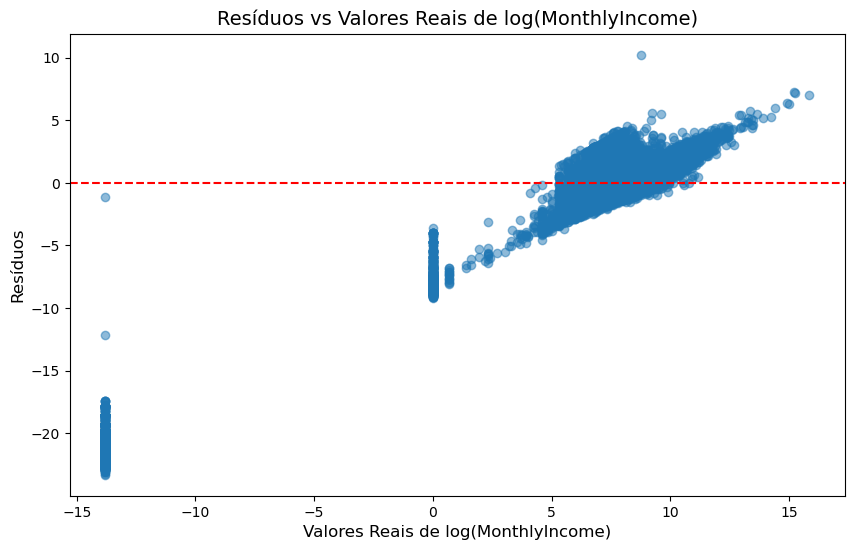

In [ ]:
y_pred = np.exp(y_pred)

resid = y.values - gam.predict(X.values)
sigma = resid.std()

plt.figure(figsize=(10, 6))
plt.scatter(y.values, resid, alpha=0.5)
plt.title("Resíduos vs Valores Reais de log(MonthlyIncome)", fontsize=14)
plt.xlabel("Valores Reais de log(MonthlyIncome)", fontsize=12)
plt.ylabel("Resíduos", fontsize=12)
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [ ]:
# y_pred_stoc = np.maximum(np.exp(y_pred + np.random.normal(0, sigma, size=y_pred.shape)), 0)

df_imputed = df.copy()
df_imputed.loc[mask_missing, 'MonthlyIncome'] = y_pred

In [ ]:
print(f"Valores imputados → min={y_pred.min():.2f}, max={y_pred.max():.2f}, média={y_pred.mean():.2f}")

assert (df_imputed['MonthlyIncome'] >= 0).all(), "Há valores negativos imputados!"

Valores imputados → min=37.05, max=22937.62, média=3671.61


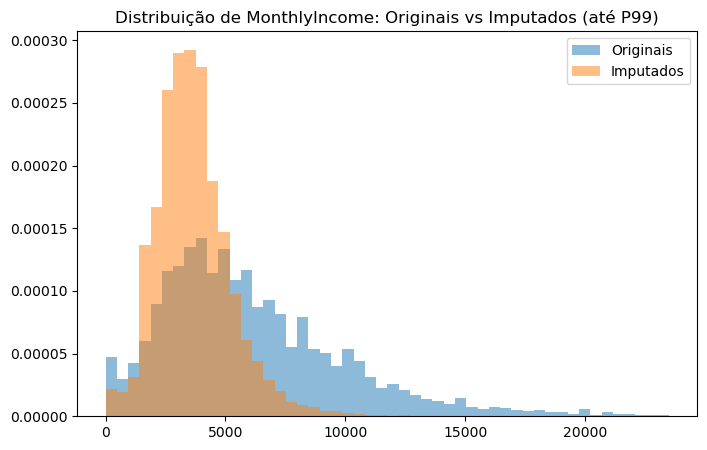

In [ ]:
data_original = df.loc[mask_complete, 'MonthlyIncome'].dropna()
data_imputed = df_imputed.loc[mask_missing, 'MonthlyIncome'].dropna()

all_data = pd.concat([data_original, data_imputed])
upper_limit = np.percentile(all_data, 99)

plt.figure(figsize=(8,5))
plt.hist(data_original, bins=50, alpha=0.5, label='Originais', range=(0, upper_limit),  density =True,)
plt.hist(data_imputed, bins=50, alpha=0.5, label='Imputados', range=(0, upper_limit),  density =True,)
plt.legend()
plt.title("Distribuição de MonthlyIncome: Originais vs Imputados (até P99)")
plt.show()

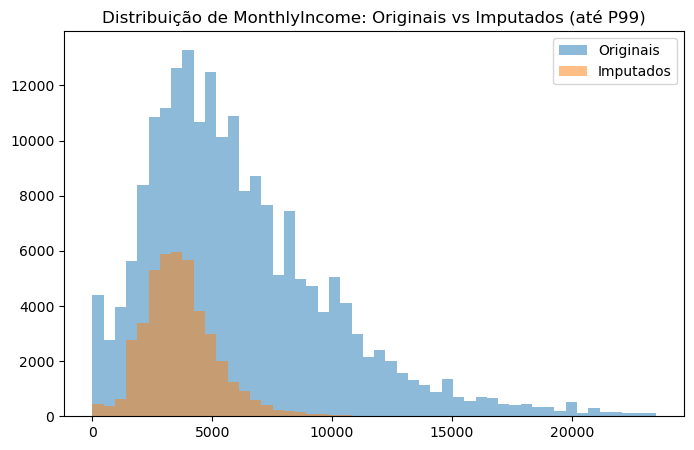

In [ ]:
data_original = df.loc[mask_complete, 'MonthlyIncome'].dropna()
data_imputed = df_imputed.loc[mask_missing, 'MonthlyIncome'].dropna()

all_data = pd.concat([data_original, data_imputed])
upper_limit = np.percentile(all_data, 99)

plt.figure(figsize=(8,5))
plt.hist(data_original, bins=50, alpha=0.5, label='Originais', range=(0, upper_limit))
plt.hist(data_imputed, bins=50, alpha=0.5, label='Imputados', range=(0, upper_limit))
plt.legend()
plt.title("Distribuição de MonthlyIncome: Originais vs Imputados (até P99)")
plt.show()

In [ ]:
new_cols = [
    'age_x_dependents',
    'realestate_x_opencredit',
    'late_combined'
]

df_imputed.drop(columns=new_cols, inplace=True)


In [ ]:
df_tn = df_imputed[
    (df_imputed['SeriousDlqin2yrs'] == 0) | (df_imputed['SeriousDlqin2yrs'] == 1)
].copy()


df_tt = df_imputed[
    (df_imputed['SeriousDlqin2yrs'] != 0) & (df_imputed['SeriousDlqin2yrs'] != 1)
].copy()


df_tn.to_csv('df_tn.csv', index=False)

df_tt.to_csv('df_tt.csv', index=False)